## ALS Recommendation System for Student Projects (Implicit Feedback)

This notebook implements an Alternating Least Squares (ALS) recommendation system for student projects using the **implicit library** specifically designed for **implicit feedback** (interactions).

## Setup
- **Items**: Project titles in Russian from data.xlsx
- **Interactions**: User ratings from artificial_profiles_scores.pkl (converted to implicit)
- **Library**: implicit - designed for implicit feedback

In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import implicit
import warnings

warnings.filterwarnings("ignore")

/Users/antonshishkov/Projects/diploma/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
df = pd.read_excel("data_clean.xlsx", header=0)
df = df.fillna("")
df.drop_duplicates(inplace=True)
print(f"Total projects: {len(df)}")

Total projects: 1187


In [3]:
df.head()

,title_rus,title_eng,annotation,description
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про..."
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,..."
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...",Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют..."
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...


In [4]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    interactions = pickle.load(f)

print("Interaction statistics per user:")
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    print(f"  {user}: {len(ratings)} total, {len(valid_ratings)} rated")

Interaction statistics per user:
  international_relations_specialist: 18 total, 18 rated
  sociology_and_cultural_studies_researcher: 19 total, 19 rated
  economics_macro_analyst: 16 total, 16 rated
  linguistics_and_translation_specialist: 15 total, 15 rated
  software_engineer_and_developer: 15 total, 15 rated
  marketing_strategist: 17 total, 17 rated
  cultural_studies_researcher: 8 total, 8 rated
  education_specialist_and_developer: 11 total, 11 rated
  historical_researcher: 10 total, 10 rated
  media_strategist_and_cultural_analyst: 10 total, 10 rated
  legal_researcher_and_policy_analyst: 12 total, 12 rated
  psychology_researcher: 13 total, 13 rated
  geopolitics_analyst: 11 total, 11 rated
  literature_scholar: 7 total, 7 rated
  natural_language_processor: 10 total, 10 rated
  finance_strategist: 9 total, 9 rated
  ai_language_and_education_specialist: 4 total, 4 rated
  political_science_expert: 7 total, 7 rated
  pedagogy_specialist: 7 total, 7 rated
  project_manager_an

## Build User-Item Matrix (Implicit Feedback)

Convert explicit ratings to implicit feedback:
- Rating > 0 indicates an interaction
- Use rating value as confidence score

In [5]:
project_titles = df["title_rus"].tolist()
user_ids = list(interactions.keys())

print(f"Number of users: {len(user_ids)}")
print(f"Number of projects: {len(project_titles)}")

Number of users: 32
Number of projects: 1187


In [6]:
num_users = len(user_ids)
num_items = len(project_titles)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(project_titles)}

row_indices = []
col_indices = []
confidences = []

for user, user_ratings in interactions.items():
    user_idx = user_to_idx[user]
    for project_title, rating in user_ratings.items():
        if rating is not None and rating > 0 and project_title in item_to_idx:
            item_idx = item_to_idx[project_title]
            row_indices.append(user_idx)
            col_indices.append(item_idx)
            confidences.append(rating)

implicit_matrix = csr_matrix(
    (confidences, (row_indices, col_indices)), shape=(num_users, num_items)
)

print(f"Implicit matrix shape: {implicit_matrix.shape}")
print(f"Number of interactions: {len(confidences)}")
print(f"Sparsity: {len(confidences) / (num_users * num_items) * 100:.2f}%")

Implicit matrix shape: (32, 1187)
Number of interactions: 299
Sparsity: 0.79%


## Split Data into Train and Test Sets

In [7]:
from sklearn.model_selection import train_test_split

rows, cols = implicit_matrix.nonzero()
n_interactions = len(rows)

interaction_indices = np.arange(n_interactions)

train_indices, test_indices = train_test_split(
    interaction_indices, test_size=0.2, random_state=42, stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_confidences = np.array(
    [implicit_matrix[train_rows[i], train_cols[i]] for i in range(len(train_indices))]
)

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_confidences = np.array(
    [implicit_matrix[test_rows[i], test_cols[i]] for i in range(len(test_indices))]
)

train_matrix = csr_matrix(
    (train_confidences, (train_rows, train_cols)), shape=(num_users, num_items)
)

test_matrix = csr_matrix(
    (test_confidences, (test_rows, test_cols)), shape=(num_users, num_items)
)

print(f"Original interactions: {n_interactions}")
print(
    f"Training interactions: {len(train_indices)} ({len(train_indices)/n_interactions*100:.1f}%)"
)
print(
    f"Test interactions: {len(test_indices)} ({len(test_indices)/n_interactions*100:.1f}%)"
)

train_users = set(train_rows)
test_users = set(test_rows)
print(f"\nUsers in training set: {len(train_users)}")
print(f"Users in test set: {len(test_users)}")

Original interactions: 299
Training interactions: 239 (79.9%)
Test interactions: 60 (20.1%)

Users in training set: 32
Users in test set: 31


## Initialize Implicit ALS Model

In [8]:
model = implicit.als.AlternatingLeastSquares(
    factors=5,
    regularization=0.001,
    iterations=20,
    calculate_training_loss=True,
    random_state=42,
)

print("Implicit ALS model initialized:")
print(f"  - Factors: {model.factors}")
print(f"  - Regularization: {model.regularization}")
print(f"  - Iterations: {model.iterations}")
print(f"  - Calculate training loss: {model.calculate_training_loss}")

Implicit ALS model initialized:
  - Factors: 5
  - Regularization: 0.001
  - Iterations: 20
  - Calculate training loss: True


In [9]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42, stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_confidences = np.array(
    [
        implicit_matrix[final_train_rows[i], final_train_cols[i]]
        for i in range(len(final_train_indices))
    ]
)

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_confidences = np.array(
    [implicit_matrix[val_rows[i], val_cols[i]] for i in range(len(val_indices))]
)

final_train_matrix = csr_matrix(
    (final_train_confidences, (final_train_rows, final_train_cols)),
    shape=(num_users, num_items),
)
val_matrix = csr_matrix(
    (val_confidences, (val_rows, val_cols)), shape=(num_users, num_items)
)

print(f"Final training data: {len(final_train_indices)} interactions")
print(f"Validation data: {len(val_indices)} interactions")
print(f"Test data: {len(test_indices)} interactions")

print("\nUser distribution across splits:")
for user_idx in range(num_users):
    train_count = np.sum(final_train_rows == user_idx)
    val_count = np.sum(val_rows == user_idx)
    test_count = np.sum(test_rows == user_idx)
    print(
        f"  {user_ids[user_idx]}: Train={train_count}, Val={val_count}, Test={test_count}"
    )

Final training data: 191 interactions
Validation data: 48 interactions
Test data: 60 interactions

User distribution across splits:
  international_relations_specialist: Train=11, Val=3, Test=4
  sociology_and_cultural_studies_researcher: Train=12, Val=3, Test=4
  economics_macro_analyst: Train=10, Val=3, Test=3
  linguistics_and_translation_specialist: Train=10, Val=2, Test=3
  software_engineer_and_developer: Train=10, Val=2, Test=3
  marketing_strategist: Train=10, Val=3, Test=4
  cultural_studies_researcher: Train=5, Val=1, Test=2
  education_specialist_and_developer: Train=7, Val=2, Test=2
  historical_researcher: Train=6, Val=2, Test=2
  media_strategist_and_cultural_analyst: Train=6, Val=2, Test=2
  legal_researcher_and_policy_analyst: Train=7, Val=2, Test=3
  psychology_researcher: Train=8, Val=2, Test=3
  geopolitics_analyst: Train=7, Val=2, Test=2
  literature_scholar: Train=5, Val=1, Test=1
  natural_language_processor: Train=6, Val=2, Test=2
  finance_strategist: Train=6, V

## Evaluate Model

For implicit feedback, we use precision@k and AUC@k metrics instead of MSE/RMSE.

In [10]:
print("Training Implicit ALS model...")
model.fit(final_train_matrix)

print("\nTraining completed!")
print(f"Model user factors shape: {model.user_factors.shape}")
print(f"Model item factors shape: {model.item_factors.shape}")

Training Implicit ALS model...


100%|██████████| 20/20 [00:00<00:00, 2048.40it/s, loss=0.0111]


Training completed!
Model user factors shape: (32, 5)
Model item factors shape: (1187, 5)


## Evaluate Model

For implicit feedback, we use precision@k and recall@k metrics instead of MSE/RMSE.

In [11]:
def precision_at_k_custom(model, test_matrix, train_matrix, K=5):
    """Calculate precision@K for implicit feedback"""
    precisions = []
    test_users, test_items = test_matrix.nonzero()

    for user_idx in np.unique(test_users):
        user_test_items = set(test_items[test_users == user_idx])

        if len(user_test_items) == 0:
            continue

        user_items = train_matrix[user_idx]

        try:
            recs = model.recommend(
                user_idx, user_items, N=K, filter_already_liked_items=True
            )
            rec_items = [rec[0] for rec in recs]
        except:
            continue

        hits = len(set(rec_items) & user_test_items)
        precision = hits / K
        precisions.append(precision)

    return np.mean(precisions) if precisions else 0.0


def calculate_auc(model, test_matrix, train_matrix, K=100):
    """Calculate AUC score for implicit feedback"""
    aucs = []
    test_users, test_items = test_matrix.nonzero()

    for user_idx in np.unique(test_users):
        user_test_items = set(test_items[test_users == user_idx])

        if len(user_test_items) == 0:
            continue

        try:
            scores = model.user_factors[user_idx] @ model.item_factors.T
        except:
            continue

        train_items = set(train_matrix[user_idx].nonzero()[1])

        candidate_items = [i for i in range(len(scores)) if i not in train_items]

        if len(candidate_items) == 0:
            continue

        candidate_scores = [(i, scores[i]) for i in candidate_items]
        candidate_scores.sort(key=lambda x: x[1], reverse=True)

        n_relevant = len(user_test_items)
        if n_relevant == 0:
            continue

        top_k_items = [item for item, score in candidate_scores[:K]]
        hits = len(set(top_k_items) & user_test_items)

        if hits > 0:
            hit_positions = [
                top_k_items.index(item) + 1
                for item in user_test_items
                if item in top_k_items
            ]
            avg_position = np.mean(hit_positions)
            auc = (K - avg_position + 1) / K
        else:
            auc = 0.0

        aucs.append(auc)

    return np.mean(aucs) if aucs else 0.0


val_precision = precision_at_k_custom(model, val_matrix, final_train_matrix, K=5)
val_auc = calculate_auc(model, val_matrix, final_train_matrix, K=100)

print("Validation Set Performance (K=5):")
print(f"  Precision@5: {val_precision:.4f}")
print(f"  AUC: {val_auc:.4f}")

test_precision = precision_at_k_custom(model, test_matrix, final_train_matrix, K=5)
test_auc = calculate_auc(model, test_matrix, final_train_matrix, K=100)

print("\nTest Set Performance (K=5):")
print(f"  Precision@5: {test_precision:.4f}")
print(f"  AUC: {test_auc:.4f}")

Validation Set Performance (K=5):
  Precision@5: 0.0065
  AUC: 0.1094

Test Set Performance (K=5):
  Precision@5: 0.0000
  AUC: 0.0948


## Generate Recommendations

In [12]:
rated_items = {}
train_matrix_rows, train_matrix_cols = train_matrix.nonzero()
for u, i in zip(train_matrix_rows, train_matrix_cols):
    if u not in rated_items:
        rated_items[u] = set()
    rated_items[u].add(i)

print("Rated items from training set stored for each user:")
for user_idx, items in rated_items.items():
    print(f"  User {user_ids[user_idx]}: {len(items)} rated projects")

Rated items from training set stored for each user:
  User international_relations_specialist: 14 rated projects
  User sociology_and_cultural_studies_researcher: 15 rated projects
  User economics_macro_analyst: 13 rated projects
  User linguistics_and_translation_specialist: 12 rated projects
  User software_engineer_and_developer: 12 rated projects
  User marketing_strategist: 13 rated projects
  User cultural_studies_researcher: 6 rated projects
  User education_specialist_and_developer: 9 rated projects
  User historical_researcher: 8 rated projects
  User media_strategist_and_cultural_analyst: 8 rated projects
  User legal_researcher_and_policy_analyst: 9 rated projects
  User psychology_researcher: 10 rated projects
  User geopolitics_analyst: 9 rated projects
  User literature_scholar: 6 rated projects
  User natural_language_processor: 8 rated projects
  User finance_strategist: 7 rated projects
  User ai_language_and_education_specialist: 3 rated projects
  User political_sci

In [13]:
for user_idx in rated_items:
    print(f"\n{user_ids[user_idx]}:")
    user_items = train_matrix[user_idx]
    for item_idx, score in enumerate(user_items.toarray()[0]):
        if score > 0:
            print(f"  {project_titles[item_idx]}, Score: {score:.4f}")


international_relations_specialist:
  Официальная помощь развитию как инструмент внешней политики Японии, Score: 5.0000
  Политический анализ стран Азии и Африки, Score: 5.0000
  «Тройка» Северо-Восточной Азии: состояние, проблемы и перспективы сотрудничества Китая, Японии и Южной Кореи., Score: 5.0000
  Международный дискуссионный клуб кино, Score: 4.0000
  МЕДИАСЕКТОР Сопровождение Модели ООН НИУ ВШЭ “HSEMUN-26”: SMM и фото/видеосопровождение, Score: 4.0000
  Инструментарий исследования меэждународных отношений, Score: 5.0000
  Влияние США, европейских и ближневосточных государств и Турции на энергетические отношения Китая и России со странами Центральной Азии., Score: 5.0000
  Менторский проект конкурса "Высший пилотаж" по направлению "Международные отношения", Score: 5.0000
  Проект Network for Asia Vision Initiative (NAVI), Score: 5.0000
  Совершенствование механизмов государственной социальной поддержки студентов: опыт стран БРИКС, Score: 4.0000
  Медиацентр Дирекции по работе с

In [14]:
for user_idx in rated_items:
    user_items = train_matrix[user_idx]

    recs = model.recommend(user_idx, user_items, N=5, filter_already_liked_items=True)

    print(f"\n{user_ids[user_idx]}:")
    for item_idx, score in zip(recs[0], recs[1]):
        print(f"  {project_titles[item_idx]}, Score: {score:.4f}")


international_relations_specialist:
  Россия и Организация исламского сотрудничества (ОИС): оценка современного состояния взаимодействия и перспектив развития, Score: 0.7266
  Пресса о театре эпохи Оттепели, Score: 0.6193
  База данных "Общественные инициативы по сохранению культурного наследия в северо-западных регионах России", Score: 0.5158
  Россия и ваша страна: Центральная Азия, Score: 0.5158
  Библиотека научно-образовательной секции исследований Ближнего Востока и Северной Африки Школы востоковедения («Ближневосточный кабинет»)., Score: 0.5158

sociology_and_cultural_studies_researcher:
  Эффективная рабочая среда в проектных командах ВУЗов, Score: 0.6994
   Эффективная рабочая среда в проектных командах ВУЗов , Score: 0.6994
  Команда контент-продакшена для Института кино, Score: 0.6994
  Создание полноценного цифрового (или omnichannel) бизнес-проекта, готового к выходу на рынок, Score: 0.6994
  Медиасопровождение проекта Data Culture 2025/26 учебный год, Score: 0.6205

econ

## Test Different Regularization Values

In [15]:
regularization_values = [0.001, 0.01, 0.1, 1.0, 10, 100]
results = []

print("Testing different regularization values...")
for reg_value in regularization_values:
    print(f"\nTraining with regularization={reg_value}...")

    test_model = implicit.als.AlternatingLeastSquares(
        factors=5,
        regularization=reg_value,
        iterations=20,
        calculate_training_loss=True,
        random_state=42,
    )

    test_model.fit(final_train_matrix)

    val_prec = precision_at_k_custom(test_model, val_matrix, final_train_matrix, K=5)
    val_auc = calculate_auc(test_model, val_matrix, final_train_matrix, K=100)

    test_prec = precision_at_k_custom(test_model, test_matrix, final_train_matrix, K=5)
    test_auc = calculate_auc(test_model, test_matrix, final_train_matrix, K=100)

    results.append(
        {
            "regularization": reg_value,
            "val_precision": val_prec,
            "val_auc": val_auc,
            "test_precision": test_prec,
            "test_auc": test_auc,
        }
    )

    print(f"  Val Precision@5: {val_prec:.4f}, AUC: {val_auc:.4f}")
    print(f"  Test Precision@5: {test_prec:.4f}, AUC: {test_auc:.4f}")

results_df = pd.DataFrame(results)

Testing different regularization values...

Training with regularization=0.001...


100%|██████████| 20/20 [00:00<00:00, 1452.82it/s, loss=0.0111]


  Val Precision@5: 0.0065, AUC: 0.1094
  Test Precision@5: 0.0000, AUC: 0.0948

Training with regularization=0.01...


100%|██████████| 20/20 [00:00<00:00, 1916.04it/s, loss=0.0111]

  Val Precision@5: 0.0065, AUC: 0.1068

...

100%|██████████| 20/20 [00:00<00:00, 1987.49it/s, loss=0.0225]

  Val Precision@5: 0.0065, AUC: 0.0968


  Test Precision@5: 0.0000, AUC: 0.0997

Training with regularization=100...


100%|██████████| 20/20 [00:00<00:00, 2258.34it/s, loss=0.0238]

  Val Precision@5: 0.0000, AUC: 0.1035
  Test Precision@5: 0.0000, AUC: 0.0774


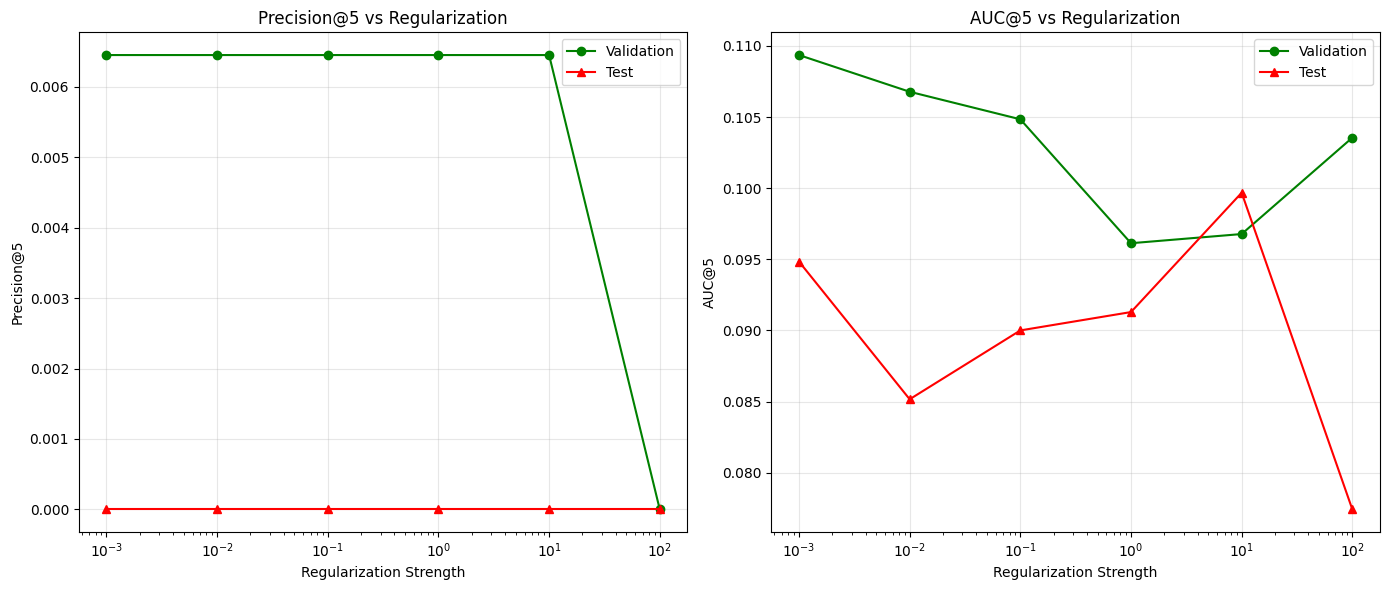

Best model based on test precision:
  Regularization: 0.001
  Test Precision@5: 0.0000
  Test AUC@5: 0.0948


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    results_df["regularization"],
    results_df["val_precision"],
    "o-",
    label="Validation",
    color="green",
)
axes[0].plot(
    results_df["regularization"],
    results_df["test_precision"],
    "^-",
    label="Test",
    color="red",
)
axes[0].set_xlabel("Regularization Strength")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Precision@5 vs Regularization")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

axes[1].plot(
    results_df["regularization"],
    results_df["val_auc"],
    "o-",
    label="Validation",
    color="green",
)
axes[1].plot(
    results_df["regularization"],
    results_df["test_auc"],
    "^-",
    label="Test",
    color="red",
)
axes[1].set_xlabel("Regularization Strength")
axes[1].set_ylabel("AUC@5")
axes[1].set_title("AUC@5 vs Regularization")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

best_idx = results_df["test_precision"].idxmax()
best_reg = results_df.loc[best_idx, "regularization"]
best_test_prec = results_df.loc[best_idx, "test_precision"]
best_test_auc = results_df.loc[best_idx, "test_auc"]

print(f"Best model based on test precision:")
print(f"  Regularization: {best_reg}")
print(f"  Test Precision@5: {best_test_prec:.4f}")
print(f"  Test AUC@5: {best_test_auc:.4f}")

## Hyperparameter Tuning: Number of Factors

In [17]:
factors_to_test = [5, 10, 20, 30, 50]
results = []

print("Testing different numbers of factors...")
for n_factors in factors_to_test:
    print(f"\nTraining with {n_factors} factors...")

    test_model = implicit.als.AlternatingLeastSquares(
        factors=n_factors,
        regularization=0.01,
        iterations=20,
        calculate_training_loss=True,
        random_state=42,
    )

    test_model.fit(final_train_matrix)

    val_prec = precision_at_k_custom(test_model, val_matrix, final_train_matrix, K=5)
    val_auc = calculate_auc(test_model, val_matrix, final_train_matrix, K=100)

    test_prec = precision_at_k_custom(test_model, test_matrix, final_train_matrix, K=5)
    test_auc = calculate_auc(test_model, test_matrix, final_train_matrix, K=100)

    results.append(
        {
            "n_factors": n_factors,
            "val_precision": val_prec,
            "val_auc": val_auc,
            "test_precision": test_prec,
            "test_auc": test_auc,
        }
    )

    print(f"  Val Precision@5: {val_prec:.4f}, AUC: {val_auc:.4f}")
    print(f"  Test Precision@5: {test_prec:.4f}, AUC: {test_auc:.4f}")

results_df = pd.DataFrame(results)

Testing different numbers of factors...

Training with 5 factors...


100%|██████████| 20/20 [00:00<00:00, 1895.73it/s, loss=0.0111]


  Val Precision@5: 0.0065, AUC: 0.1068
  Test Precision@5: 0.0000, AUC: 0.0852

Training with 10 factors...


100%|██████████| 20/20 [00:00<00:00, 1976.67it/s, loss=0.00639]


  Val Precision@5: 0.0000, AUC: 0.0835
  Test Precision@5: 0.0000, AUC: 0.1090

Training with 20 factors...


...

  Val Precision@5: 0.0000, AUC: 0.1271
  Test Precision@5: 0.0000, AUC: 0.0548

Training with 30 factors...


100%|██████████| 20/20 [00:00<00:00, 2038.94it/s, loss=0.000428]


  Val Precision@5: 0.0000, AUC: 0.0223
  Test Precision@5: 0.0000, AUC: 0.0426

Training with 50 factors...


100%|██████████| 20/20 [00:00<00:00, 1316.07it/s, loss=0.000337]

  Val Precision@5: 0.0065, AUC: 0.1042
  Test Precision@5: 0.0000, AUC: 0.1226


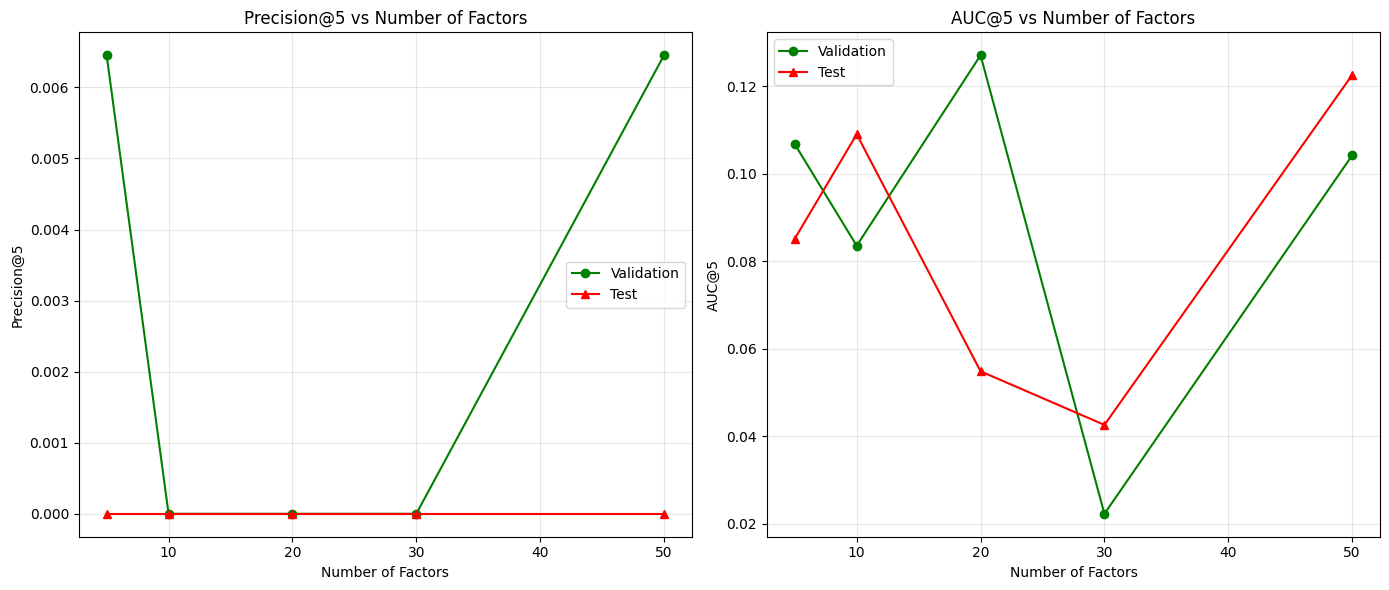

Best model based on test precision:
  Number of factors: 5
  Test Precision@5: 0.0000
  Test AUC@5: 0.0852


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    results_df["n_factors"],
    results_df["val_precision"],
    "o-",
    label="Validation",
    color="green",
)
axes[0].plot(
    results_df["n_factors"],
    results_df["test_precision"],
    "^-",
    label="Test",
    color="red",
)
axes[0].set_xlabel("Number of Factors")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Precision@5 vs Number of Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    results_df["n_factors"],
    results_df["val_auc"],
    "o-",
    label="Validation",
    color="green",
)
axes[1].plot(
    results_df["n_factors"],
    results_df["test_auc"],
    "^-",
    label="Test",
    color="red",
)
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("AUC@5")
axes[1].set_title("AUC@5 vs Number of Factors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_df["test_precision"].idxmax()
best_n_factors = results_df.loc[best_idx, "n_factors"]
best_test_prec = results_df.loc[best_idx, "test_precision"]
best_test_auc = results_df.loc[best_idx, "test_auc"]

print(f"Best model based on test precision:")
print(f"  Number of factors: {best_n_factors}")
print(f"  Test Precision@5: {best_test_prec:.4f}")
print(f"  Test AUC@5: {best_test_auc:.4f}")

## Save Model for Future Use

In [19]:
model_data = {
    "user_factors": model.user_factors,
    "item_factors": model.item_factors,
    "user_ids": user_ids,
    "item_ids": project_titles,
    "rated_items": rated_items,
    "train_data": {
        "rows": final_train_rows,
        "cols": final_train_cols,
        "confidences": final_train_confidences,
    },
    "val_data": {"rows": val_rows, "cols": val_cols, "confidences": val_confidences},
    "test_data": {
        "rows": test_rows,
        "cols": test_cols,
        "confidences": test_confidences,
    },
    "model_params": {
        "factors": model.factors,
        "regularization": model.regularization,
        "iterations": model.iterations,
        "random_state": 42,
    },
    "performance": {
        "val_precision": val_precision,
        "val_auc": val_auc,
        "test_precision": test_precision,
        "test_auc": test_auc,
    },
}

with open("als_model_implicit.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Implicit ALS model saved to implicit_als_model.pkl")

Implicit ALS model saved to implicit_als_model.pkl
